### Retinal vessel detection 
Stanisław Marszałek 160167 </br>
Łukasz Przykłota 159440

### Importing libraries and creating constants

In [1]:
import numpy as np
from copy import deepcopy
import os 
import ipywidgets as widgets
from IPython.display import display
import warnings
import cv2
import torch
import gc

from image_processing import read_img,show_img, draw_vessels, preproces_pipeline, postproces_pipeline
from classic_version import classic_vessel_segmentation
from simple_statistics import create_confusions_matrix
from ml_utilitis import load_model,predict_full_image, remove_small_components

from UNet import UNet
#Supressing warrnigns
warnings.filterwarnings("ignore")

#CONSTANTS
INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"
SAVED_MODELS:str="./saved_models"

#PATHS
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]


#przemyslec zrobienie z size parametru
size = 512

### Choosing method and images

In [2]:
method=widgets.Combobox(

    placeholder='Choose the method to find vessels',
    options=["Sato filtr","Random Forrest Model","UNet (Neural Network)"],
    description='Method',
    ensure_option=True,
    disabled=False,
    layout=widgets.Layout(width='auto')
)
images = widgets.SelectMultiple(
    # hold CTRL to choose more than one
    options=input_images,
    value=[],
    description='Images',
    disabled=False
)
show_confussion_matrix=widgets.Checkbox(
    value=False,
    description='Show confussion matrix',
    disabled=False,
    layout=widgets.Layout(width='auto')
)
sliders=widgets.VBox([method,show_confussion_matrix,images],layout=widgets.Layout(width='45%'))
display(sliders)

### Choosing paramteres/models

In [13]:
are_chosen:bool=False
if method.value!="":
    if method.value=="Sato filtr":
        threshold=widgets.FloatSlider(
        value=0.0085,
        min=0.001,
        max=0.02,
        step=0.0005,
        description='Threshold:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.4f',
        layout=widgets.Layout(width='auto')
        )
        median_kernel_size=widgets.IntSlider(
        value=11,
        min=3,
        max=21,
        step=2,
        description='Median Kernel Size:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        layout=widgets.Layout(width='auto')
        )
        filling_kernel_size=widgets.IntSlider(
        value=17,
        min=3,
        max=21,
        step=2,
        description='Filling Kernel Size:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        layout=widgets.Layout(width='auto')
        )
        are_chosen=True
        sliders=widgets.VBox([threshold,median_kernel_size,filling_kernel_size],layout=widgets.Layout(width='45%'))
       
        
    else:
        widgets_list=[]
        if method.value=="Random Forrest Model":
            models=[SAVED_MODELS+"/"+file.name for file in os.scandir(SAVED_MODELS) if file.is_file() and file.name.endswith("pkl")]
            
            min_component_size=widgets.IntSlider(
            value=100,
            min=75,
            max=200,
            step=5,
            description='Min size',
            disabled=False,
            continuous_update=False,
            orientation='horizontal',
            layout=widgets.Layout(width='auto')
            )
            widgets_list.append(min_component_size)

            morph_kernell_size=widgets.IntSlider(
            value=13,
            min=3,
            max=23,
            step=2,
            description='Morph size',
            disabled=False,
            continuous_update=False,
            orientation='horizontal',
            layout=widgets.Layout(width='auto')
            )
            widgets_list.append(morph_kernell_size)

        elif method.value=="UNet (Neural Network)":
            models=[SAVED_MODELS+"/"+file.name for file in os.scandir(SAVED_MODELS) if file.is_file() and file.name.endswith("pth")]
        
        if models:
            first_model=models[0]
            are_chosen=True
        else:
            are_chosen=False
            #False because there is no model to choose

        model_path=widgets.Combobox(
            value=first_model,
            options=models,
            description='Model',
            ensure_option=True,
            disabled=False,
            layout=widgets.Layout(width='auto')
        )
        
        widgets_list.append(model_path)
        sliders=widgets.VBox(widgets_list,layout=widgets.Layout(width='45%'))
     
    display(sliders)   
    
    

### Looking for vessels

(1, 3, 512, 512)


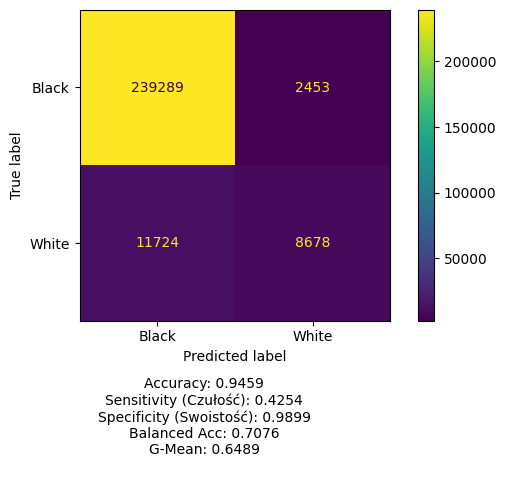

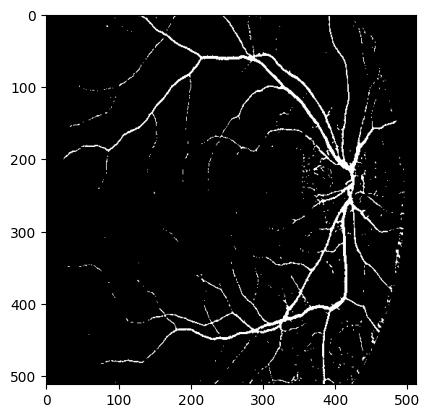

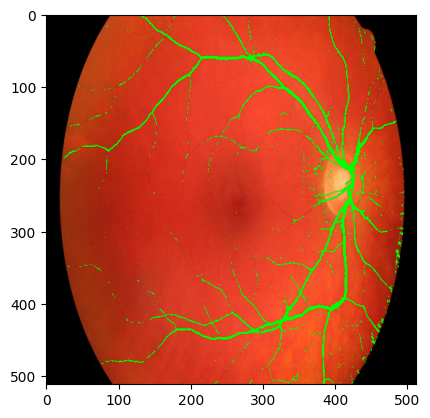

(1, 3, 512, 512)


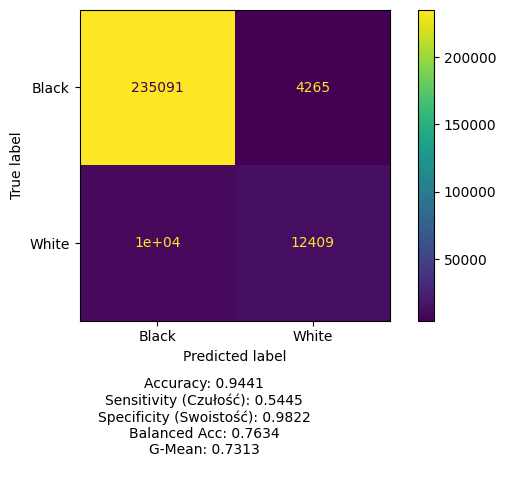

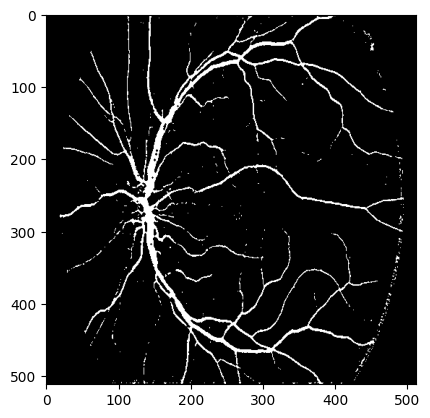

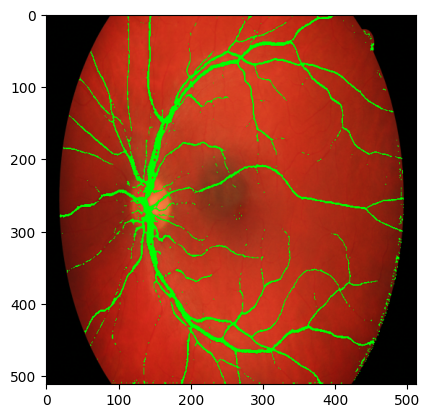

In [14]:
if method.value!="" and images.value!=() and are_chosen:
    data=[[str(image_path)] for image_path in images.value]
    #Looking for FOV paths
    for single_list in data:
        name=single_list[0].replace(INPUT_DIR+"/","").replace(".jpg","").replace(".JPG","")
        for fov_path in mask_images:
            if name in fov_path:
                single_list.append(fov_path)
                break
        else:
            raise ValueError("FOV musk not found\nPlease check if the FOV mask is in `mask` directory\n and if its name suits the naming pattern")

        if show_confussion_matrix.value:
            for expert_path in manual_images:
                if name in expert_path:
                    single_list.append(expert_path)
                    break
            else:
                raise ValueError("Expert musk not found\nPlease check if the expert mask is in `manual1` directory\n and if its name suits the naming pattern")
    
    for single_list in data:
        gc.collect()
        img=read_img(single_list[0])
        fov_mask=read_img(single_list[1])

        

        if method.value== "Sato filtr":
            img_copy=deepcopy(img)
            vessels=classic_vessel_segmentation(img,fov_mask,threshold=threshold.value,
                                                median_kernel_size=median_kernel_size.value,
                                                filling_kernel_size=filling_kernel_size.value)
        

        elif method.value=="Random Forrest Model":
            img_copy=deepcopy(img)
            model=load_model(model_path.value)
            vessels=predict_full_image(img,fov_mask,model,preproces_pipeline)
            vessels=remove_small_components(vessels,min_size=min_component_size.value)
            
            vessels=postproces_pipeline(vessels,kernel_size=morph_kernell_size.value)


        elif method.value=="UNet (Neural Network)":
            #Jak pozbyc sie fov mask z danych dla DL

            device="cuda" if torch.cuda.is_available() else "cpu"
            #Cleaning GPU memory before alocation
            torch.cuda.empty_cache()
            model = UNet(1).to(device)
            model.load_state_dict(torch.load(model_path.value, weights_only=True))
            
            img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
            fov_mask = cv2.resize(fov_mask, (size, size), interpolation=cv2.INTER_AREA)
            img_copy=deepcopy(img)

            img = np.transpose(img, (2, 0, 1))          # HWC -> CHW
            img = np.expand_dims(img, axis=0)           # CHW -> NCHW
            
            print(img.shape)
            X = torch.tensor(img, dtype=torch.float32, device=device)
            with torch.no_grad():
                vessels = model(X)
                vessels = torch.sigmoid(vessels)
                vessels = (vessels > 0.5).float()
            vessels = vessels.squeeze(0).squeeze(0).cpu().numpy().astype(np.uint8)
            if len(fov_mask.shape)>1:
                fov_mask=fov_mask[:,:,1]
            
            vessels&=fov_mask
            vessels=postproces_pipeline(vessels,3)
            ### DODAC DO GUI ROZMIAR FILTRA DO WYBORU
        ###WYSIETLANIE MACIZERYZ POMYLEK DO POPRAWY
        if show_confussion_matrix.value:
            expert_mask=read_img(single_list[2])
            expert_mask=expert_mask[:,:,1]
            expert_mask=np.where(expert_mask>0,1,0).astype(np.uint8)
            if method.value=="UNet (Neural Network)":
                expert_mask = cv2.resize(expert_mask, (size, size), interpolation=cv2.INTER_NEAREST)
            create_confusions_matrix(expert_mask,vessels)
        
        show_img(vessels)
        cp=draw_vessels(img_copy,vessels)
        show_img(cp)
